# Sea ice: climatological bias of the CAMulator checkpoints

The **multi-year mean** bias, which is what the thesis needs. One checkpoint per
run: set `CASE` below and re-run the notebook.

For a single year month-by-month — maps, conservation check, extent time series —
see `ice_comparison.ipynb` instead. The two notebooks share the same package and
the same weight file; they answer different questions.

`bias = checkpoint − reference`. **Positive means the checkpoint has too much ice.**
That holds in both figures and in the area numbers.

Two input facts that are easy to get wrong and silent when you do:

- The reference is **one zarr store per calendar year**, 1980–2014. `REFERENCE` below
  is a `*` glob so every year in the window is opened. A single-store path would make
  a "5-year mean" secretly a one-year mean.
- POP stamps a monthly file at the **end** of its averaging interval, so
  `pop.h.1980-01.nc` — the January mean — carries a time of 1980-02-01.
  `climatology()` uses the `time_bound` midpoint instead. Selecting on the raw stamp
  shifts the whole seasonal cycle by one month.

**Kernel:** needs `xesmf` — use the NPL kernel, not the default JupyterHub one.


In [1]:
%load_ext autoreload
%autoreload 2


## Knobs

Everything this notebook does is set here. `CASE`, `MONTHS`, `YEARS` and `HEMI`
are the four you actually change.


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from ice_ens import (
    bias_ensemble,
    climatology,
    data,
    grids,
    ice_area,
    plot_area_error,
    plot_bias_grid,
    plot_month_grid,
    regrid_to_gx1v7,
)

# ----------------------------------------------------------------- knobs ----
CASE = "ck36"  # <- the checkpoint. Change this and re-run the notebook.
MONTHS = [6, 7, 8]  # [8] = August; [6, 7, 8] = a JJA mean; [3] = the max
YEARS = ("1980", "1986")  # inclusive window; BOTH sides are averaged over it
HEMI = "south"  # 'north' or 'south'

# How far each case actually runs -- all of them start 1980-01. A window that runs
# past the end is skipped, loudly, rather than quietly averaged over fewer years:
#   ck70 -> 1990-10    ck33 -> 1990-05    ck36 -> 1987-12
#   ck69 -> 1987-05    ck66 -> 1985-12    ck64 -> 1981-12 only
CHECKPOINTS = {CASE: f"/glade/derecho/scratch/liyuanpu/g.e21.CAMULATOR_POP_{CASE}/run"}

# One store per calendar year -- keep the '*'.
REFERENCE = (
    "/glade/derecho/scratch/wchapman/b_credit_runs/"
    "b.e21.CREDIT_climate_branch_1980_*_zmdata_ERA5scaled_zmdata_Qtot.zarr"
)
REF_VAR = "ICEFRAC"

WEIGHTS = f"{data.WEIGHT_DIR}/conservative_ref192x288_to_gx1v7_384x320.nc"
FIG_DIR = data.out_dir(CASE, "ensemble")  # -> output/<CASE>/ensemble/, created
print("figures ->", FIG_DIR)

figures -> /glade/work/tvoeller/honors_thesis/code/output/ck36/ensemble


### Run it

The reference is climatologied once and regridded once; every checkpoint in
`CHECKPOINTS` reuses it. The printout is the receipt — check the timestep counts before
you trust the maps. Aug 1980–1984 should be **5** for a checkpoint (five monthly means)
and **620** for the reference (5 × 31 days × 4 samples/day, it is 6-hourly).

The first run builds the ESMF weights and takes a couple of minutes; after that the
weight file is reused and a run is ~30 s.

In [16]:
biases, areas = bias_ensemble(
    CHECKPOINTS,
    reference_path=REFERENCE,
    months=MONTHS,
    years=YEARS,
    hemisphere=HEMI,
    ref_var=REF_VAR,
    weights_path=WEIGHTS,
)

reference  ICEFRAC  2576 timesteps, 1980-1986 months [6, 7, 8]: south ice area 13.261 x10^6 km2
  ck36: 21 timesteps, south ice area 15.584, error +2.323 x10^6 km2


/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/xesmf/frontend.py:716: UserWarning: Using dimensions ('latitude', 'longitude') from data variable ICEFRAC as the horizontal dimensions for the regridding.
  warnings.warn(


### Use this to build single plots, eaither avergaged multi month or single month climatology differnces. 

wrote /glade/work/tvoeller/honors_thesis/code/output/ck36/ensemble/bias_grid_m06-07-08_1980-1986_south.png


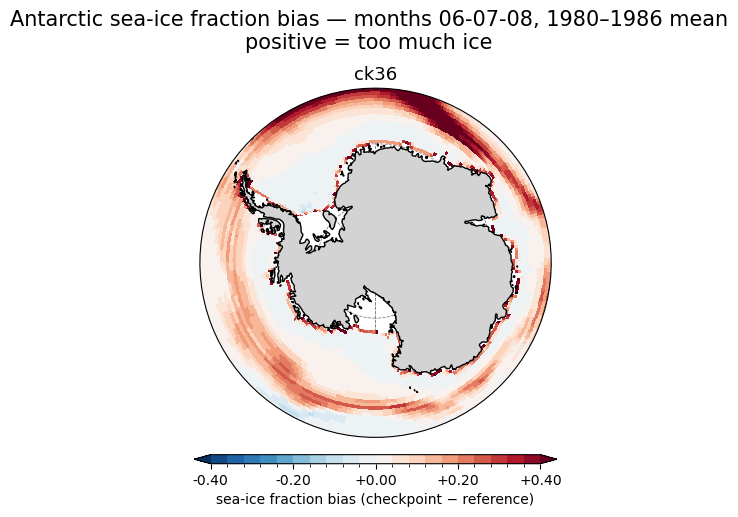

In [17]:
fig = plot_bias_grid(biases, HEMI, fig_dir=FIG_DIR)
plt.show()

wrote /glade/work/tvoeller/honors_thesis/code/output/ck36/ensemble/area_error_m06-07-08_1980-1986_south.png


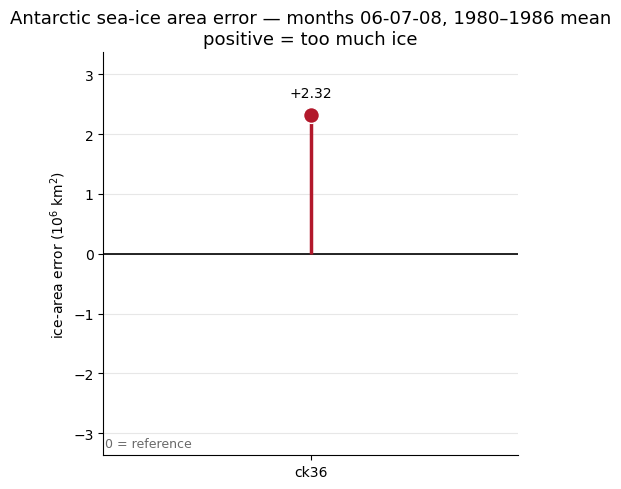

In [18]:
fig = plot_area_error(areas, HEMI, fig_dir=FIG_DIR, months=MONTHS, years=YEARS)
plt.show()

## One panel per month, instead of a seasonal mean

`MONTHS = [6, 7, 8]` in a single run gives **one** field — the JJA mean. To see the
three months side by side, call `bias_ensemble` once per month and key the dict by
**month name** instead of by checkpoint. `plot_bias_grid` draws one panel per key and
does not care what the keys mean, so all three land on one shared colorbar.

Worth doing: a seasonal mean hides that the central-Arctic deficit *grows* through the
summer while the Barents/Greenland excess sits there the whole time. Those two partly
cancel, which is why ck33's area error is **largest in June** (+0.63) even though the
June map looks the mildest.

`title=` and `name=` are needed here, not decoration — without them the figure is
captioned as a seasonal mean and its filename collides with the real seasonal-mean
figure.

Same trick for several checkpoints at once: loop over cases too and key on
`f'{case} {label}'`.

In [21]:
from ice_ens.plot_poles import MONTH_NAMES

SEASON = [1,2,3,4,5,6, 7, 8, 9, 10, 11, 12]  # <- each of these gets its own panel

biases_by_month, areas_by_month = {}, {}
for m in SEASON:
    b, a = bias_ensemble(
        CHECKPOINTS,
        reference_path=REFERENCE,
        months=[m],
        years=YEARS,
        hemisphere=HEMI,
        ref_var=REF_VAR,
        weights_path=WEIGHTS,
    )
    label = MONTH_NAMES[m - 1]  # 'June', 'July', 'August'
    biases_by_month[label] = b[CASE]
    areas_by_month[label] = a[CASE]

reference  ICEFRAC  868 timesteps, 1980-1986 months [1]: south ice area 4.250 x10^6 km2


/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/xesmf/frontend.py:716: UserWarning: Using dimensions ('latitude', 'longitude') from data variable ICEFRAC as the horizontal dimensions for the regridding.
  warnings.warn(


  ck36: 7 timesteps, south ice area 5.632, error +1.382 x10^6 km2
reference  ICEFRAC  784 timesteps, 1980-1986 months [2]: south ice area 1.914 x10^6 km2


/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/xesmf/frontend.py:716: UserWarning: Using dimensions ('latitude', 'longitude') from data variable ICEFRAC as the horizontal dimensions for the regridding.
  warnings.warn(


  ck36: 7 timesteps, south ice area 2.863, error +0.949 x10^6 km2
reference  ICEFRAC  868 timesteps, 1980-1986 months [3]: south ice area 2.428 x10^6 km2


...

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/xesmf/frontend.py:716: UserWarning: Using dimensions ('latitude', 'longitude') from data variable ICEFRAC as the horizontal dimensions for the regridding.
  warnings.warn(


  ck36: 7 timesteps, south ice area 17.006, error +2.286 x10^6 km2
reference  ICEFRAC  840 timesteps, 1980-1986 months [11]: south ice area 13.009 x10^6 km2


/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/xesmf/frontend.py:716: UserWarning: Using dimensions ('latitude', 'longitude') from data variable ICEFRAC as the horizontal dimensions for the regridding.
  warnings.warn(


  ck36: 7 timesteps, south ice area 14.910, error +1.900 x10^6 km2
reference  ICEFRAC  868 timesteps, 1980-1986 months [12]: south ice area 9.322 x10^6 km2
  ck36: 7 timesteps, south ice area 11.047, error +1.725 x10^6 km2


/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/xesmf/frontend.py:716: UserWarning: Using dimensions ('latitude', 'longitude') from data variable ICEFRAC as the horizontal dimensions for the regridding.
  warnings.warn(


wrote /glade/work/tvoeller/honors_thesis/code/output/ck36/ensemble/bias_grid_ck36_Jan-Feb-Mar-Apr-May-Jun-Jul-Aug-Sep-Oct-Nov-Dec_separate_1980-1986_south.png


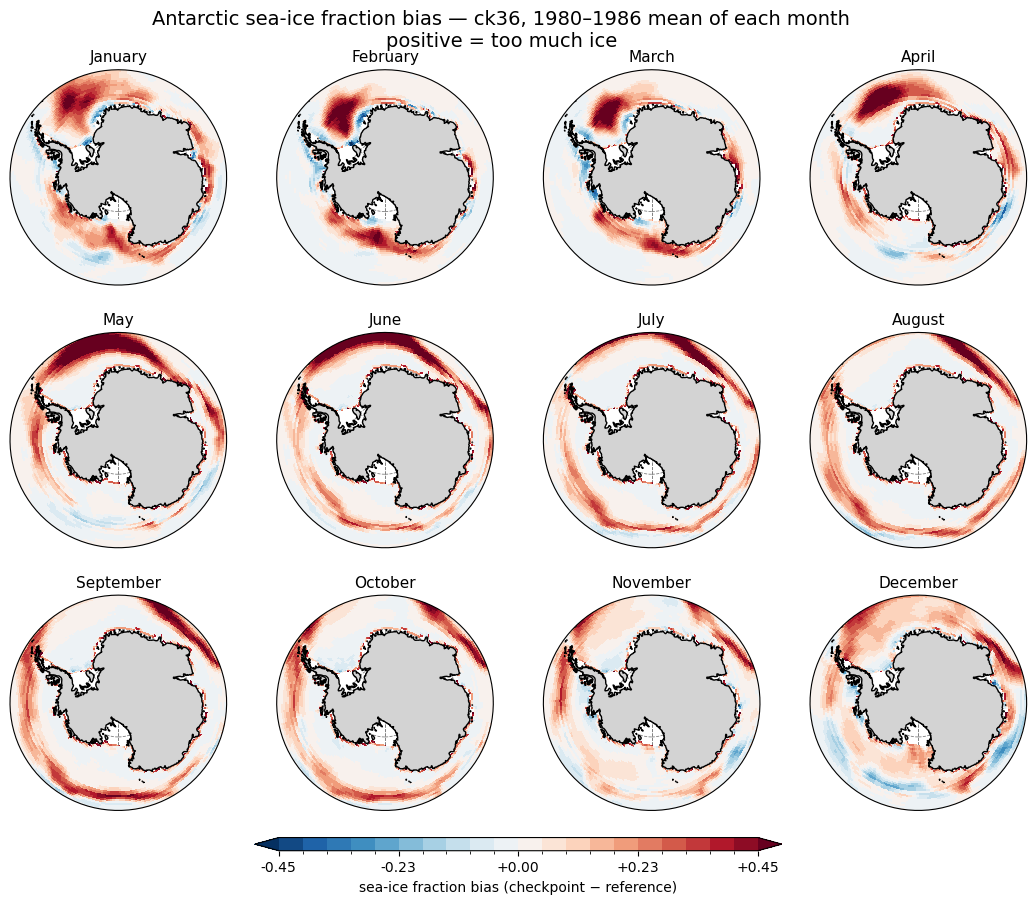

wrote /glade/work/tvoeller/honors_thesis/code/output/ck36/ensemble/area_error_ck36_Jan-Feb-Mar-Apr-May-Jun-Jul-Aug-Sep-Oct-Nov-Dec_separate_1980-1986_south.png


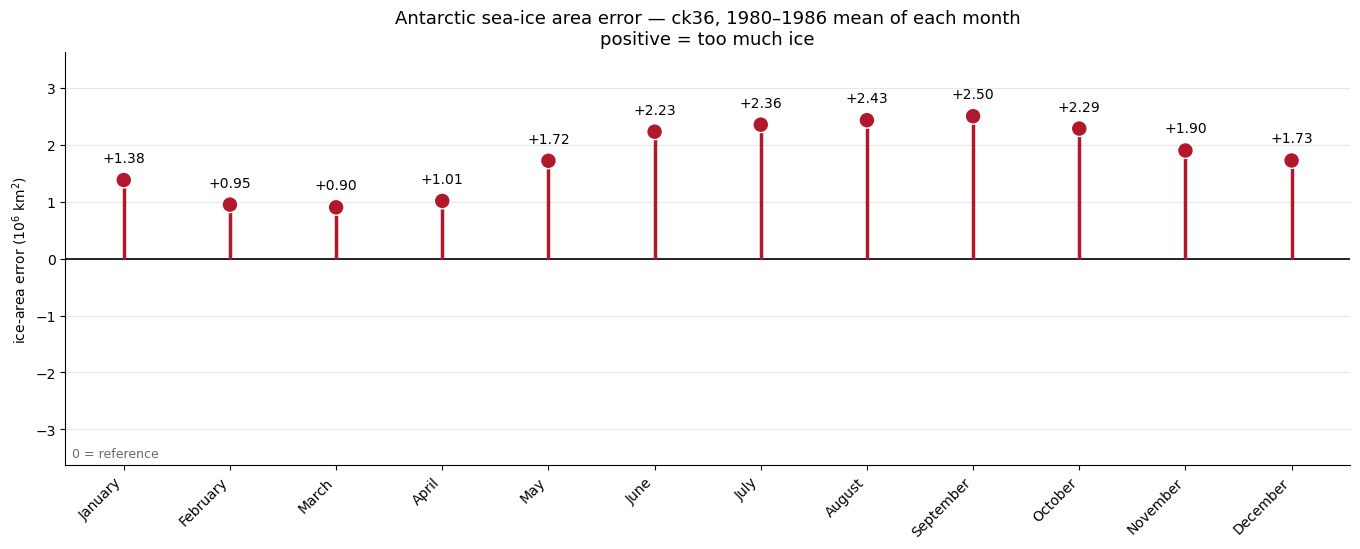

In [23]:
pole = "Arctic" if HEMI == "north" else "Antarctic"
season = "-".join(MONTH_NAMES[m - 1][:3] for m in SEASON)  # 'Jun-Jul-Aug'
stem = f"{CASE}_{season}_separate_{YEARS[0]}-{YEARS[1]}"

fig = plot_bias_grid(
    biases_by_month,
    HEMI,
    fig_dir=FIG_DIR,
    name=stem,
    title=f"{pole} sea-ice fraction bias — {CASE}, {YEARS[0]}–{YEARS[1]} mean of "
    f"each month\npositive = too much ice",
)
plt.show()

fig = plot_area_error(
    areas_by_month,
    HEMI,
    fig_dir=FIG_DIR,
    name=stem,
    title=f"{pole} sea-ice area error — {CASE}, {YEARS[0]}–{YEARS[1]} mean of "
    f"each month\npositive = too much ice",
)
plt.show()

## The whole seasonal cycle: one panel per month

`plot_month_grid` does in one call what the two cells above do by hand — except for
twelve months instead of three, laid out 4 across and 3 down.

**Twelve separate climatologies, not an annual mean.** Each month gets its own
multi-year average on *both* sides, so the seasonal cycle of the bias stays visible
instead of averaging itself away. All twelve panels share one colorbar, scaled from all
twelve together, so they are comparable by eye.

- `months=[3, 6, 9, 12]` for a subset — any list works, and the layout follows the count.
- `vmax=0.5` pins the colour scale. Do this once you are running checkpoints one at a
  time, or each figure picks its own scale from its own data and two figures cannot be
  compared side by side.
- One checkpoint per call, on purpose. Two would be 24 panels; run it once per `CASE`.
- A month the checkpoint cannot cover over `YEARS` is skipped with a message rather than
  quietly averaged over fewer years.

About two minutes for a full year — roughly ten seconds a month, most of it reading the
reference. It writes `bias_grid_<CASE>_bymonth_<window>_<hemi>.png` and the matching
`area_error_...`, so it does not collide with the seasonal-mean figures above.

The cell above is the version to edit if you need the loop itself to do something
different; this one is the version to call when you just want the year.


In [ ]:
fig, biases_by_month, areas_by_month = plot_month_grid(
    CHECKPOINTS[CASE],
    REFERENCE,
    YEARS,
    HEMI,
    label=CASE,
    ref_var=REF_VAR,
    weights_path=WEIGHTS,
    fig_dir=FIG_DIR,
)
plt.show()


### Confirming the coastal artifact yourself

The reference's only sea-ice variable is CAM's `ICEFRAC` = ice area / **total** cell
area. The checkpoint reports POP's `IFRAC` = ice area / the cell's **ocean** part. On a
cell that is partly land, `ICEFRAC ≤ IFRAC` for the same physical ice — so the
reference reads too *low* at the coast, and `checkpoint − reference` is pushed *up*.
The prediction is a spurious **positive** (too-much-ice) bias hugging every coastline.

How to check it rather than believe it. The reference's own sea fraction is
`1 − LANDFRAC`; push it through the **same** regridder, and it says how much of each
gx1v7 cell was ocean *in the reference*. 1.0 means no land was involved. Then:

1. Bin the bias by that sea fraction. If the artifact is real, the mean bias climbs
   steadily as the sea fraction falls — and it does, by roughly a factor of ten
   between open ocean and the most land-contaminated cells.
2. Divide the regridded `ICEFRAC` by the sea fraction to undo the dilution, and compare.
   **The tell:** coastal cells move a lot, open-ocean cells do not move at all. A real
   model error would move both.

Note this does **not** contaminate the area numbers above — those never touch a
regridded field.

In [11]:
land = climatology(REFERENCE, MONTHS, YEARS, var="LANDFRAC")

ref_g = regrid_to_gx1v7(ref, ck, weights_path=WEIGHTS)  # ICEFRAC on gx1v7
sea_g = regrid_to_gx1v7(1.0 - land, ck, weights_path=WEIGHTS)  # sea fraction, same map

bias = ck - ref_g
hemi = ck["TLAT"] >= 0 if HEMI == "north" else ck["TLAT"] < 0

print(f"{CASE}  {HEMI}  months {MONTHS}  {YEARS[0]}-{YEARS[1]}")
print(f'{"reference sea fraction":>24s} {"cells":>7s} {"mean bias":>11s}')
for lo, hi in [(0.0, 0.5), (0.5, 0.9), (0.9, 0.99), (0.99, 0.999), (0.999, 1.001)]:
    sel = hemi & (sea_g >= lo) & (sea_g < hi)
    print(
        f"{lo:12.3f} - {hi:<9.3f} {int(sel.sum()):7d} "
        f"{float(bias.where(sel).mean()):+11.4f}"
    )

# Undo the dilution and see which cells move.
undiluted = (ref_g / sea_g.where(sea_g >= 0.05)).clip(0.0, 1.0)
coast = hemi & (sea_g < 0.99)
open_ocean = hemi & (sea_g >= 0.99)

print()
for name, b in (("raw", bias), ("un-diluted", ck - undiluted)):
    print(
        f"{name:>11s}   coastal cells {float(b.where(coast).mean()):+.4f}"
        f"   open-ocean cells {float(b.where(open_ocean).mean()):+.4f}"
    )

NameError: name 'ref' is not defined

## Turning the knobs

- `MONTHS = [6, 7, 8]` for a JJA mean, `[3]` for the Arctic maximum, `[9]` for the
  minimum. Selection happens in exactly one place, `climatology()` in
  `ice_ens/ensemble.py` — nowhere else.
- `HEMI = 'south'` for the Antarctic. The polar projection, the hemisphere mask and
  the filenames all follow it.
- `YEARS` is inclusive and applies to **both** sides. 1980–1989 is the longest window
  any checkpoint covers (ck33 and ck70 only).
- `plot_bias_grid(biases, HEMI, fig_dir=FIG_DIR, vmax=0.5)` pins the colour scale.
  Worth doing once you are running checkpoints one at a time — otherwise each figure
  picks its own scale from its own data and they are not comparable side by side.
- Put several entries in `CHECKPOINTS` to get them all in one figure with one shared
  colorbar. Any case that does not cover `YEARS` is skipped with a message.

See `README.md` for the sign convention, why the checkpoints are never regridded, and
the **Things to mention while building** notes.

### How the area error is calculated

`areas[CASE]` is `checkpoint_area − reference_area` in 10⁶ km², positive = too much ice.
Each side is totalled on its **own native grid** — nothing here is regridded:

| side | sum | why it is real ice area |
|---|---|---|
| checkpoint | `sum(IFRAC × TAREA)` over cells with `TLAT ≥ 0` | gx1v7's land mask is binary, so an ocean cell is *wholly* ocean — `IFRAC × TAREA` is ice area, not a diluted fraction. `TAREA` is in cm², hence the `× 1e-4`. |
| reference | `sum(ICEFRAC × cell_area)` on the 192×288 grid | `ICEFRAC` is ice / *total* cell area, so `× total area` gives ice area back. Cell areas come from `grids.cell_area(grids.f09_grid(...))`. |

Then `× 1e-12` for m² → 10⁶ km². Cells outside the ocean mask are NaN and drop out of
the sum on their own.

Two consequences worth knowing:

- **The number does not inherit any regridding error**, and it does not inherit the
  coastal `ICEFRAC`/`IFRAC` dilution artifact either (next section). That is the whole
  reason `ice_area` is called on native grids instead of after the regrid.
- **The reference is averaged over the same `MONTHS`/`YEARS` as the checkpoint** — not
  over a longer baseline. For a long-term reference climatology instead, call
  `climatology(REFERENCE, MONTHS, ('1980', '2014'), var=REF_VAR)` yourself and compare
  against that; it answers a different question.

The next cell recomputes the error by hand so none of the above has to be taken on
faith.

In [ ]:
ck = climatology(CHECKPOINTS[CASE], MONTHS, YEARS, var="IFRAC")
ref = climatology(REFERENCE, MONTHS, YEARS, var=REF_VAR)

# checkpoint: POP's own TAREA (cm2 -> m2) and TLAT, on gx1v7
ck_area = ice_area(ck, ck["TAREA"] * 1e-4, ck["TLAT"], HEMI)

# reference: its own cell areas and latitudes, on the native 192x288 lat/lon grid
ref_cell = xr.DataArray(
    grids.cell_area(grids.f09_grid(ref)),
    dims=("latitude", "longitude"),
    coords={"latitude": ref["latitude"], "longitude": ref["longitude"]},
)
ref_area = ice_area(ref, ref_cell, ref["latitude"], HEMI)

print(
    f"checkpoint {CASE:<10s} {ck_area:7.3f}   ({ck.attrs['n_times']} timesteps, "
    f"years {ck.attrs['years_present']})"
)
print(
    f"reference  {REF_VAR:<10s} {ref_area:7.3f}   ({ref.attrs['n_times']} timesteps, "
    f"years {ref.attrs['years_present']})"
)
print(f"error      {'':<10s} {ck_area - ref_area:+7.3f}   x10^6 km2")
print()
print("matches bias_ensemble:", abs((ck_area - ref_area) - areas[CASE]) < 1e-9)